In [ ]:
from google.colab import files
uploaded = files.upload()

Saving movies.csv to movies.csv


## Feature Engineering & PCA

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ===============================
# 1. LOAD DATA
# ===============================
df = pd.read_csv("movies.csv")

# ===============================
# 2. FEATURE ENGINEERING
# ===============================

# ROI (already exists, but ensure correctness)
df["roi"] = (df["revenue_usd"] - df["budget_usd"]) / df["budget_usd"]

# Release Season
def map_season(month):
    if month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    elif month in [9, 10, 11]:
        return "Fall"
    else:
        return "Winter"

df["release_season"] = df["release_month"].apply(map_season)

# Director Impact Score (mean rating of director's movies)
director_impact = (
    df.groupby("director")["vote_average"]
    .mean()
    .to_dict()
)

df["director_impact"] = df["director"].map(director_impact)

# ===============================
# 3. GENRE ONE-HOT ENCODING
# ===============================

genre_dummies = df["genres"].str.get_dummies(sep=", ")
df = pd.concat([df, genre_dummies], axis=1)

# ===============================
# 4. LOG TRANSFORMATION (FINANCIAL SKEW HANDLING)
# ===============================

df["log_budget"] = np.log1p(df["budget_usd"])
df["log_revenue"] = np.log1p(df["revenue_usd"])
df["log_vote_count"] = np.log1p(df["vote_count"])
df["log_popularity"] = np.log1p(df["popularity"])

# ===============================
# 5. SELECT NUMERICAL FEATURES FOR PCA
# ===============================

numerical_features = [
    "log_budget",
    "log_revenue",
    "roi",
    "runtime_minutes",
    "vote_average",
    "log_vote_count",
    "log_popularity",
    "director_impact"
]

# Add encoded genres
numerical_features.extend(genre_dummies.columns.tolist())

X = df[numerical_features].fillna(0)

# ===============================
# 6. STANDARDIZATION
# ===============================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ===============================
# 7. PCA (DIMENSIONALITY REDUCTION)
# ===============================

pca = PCA(n_components=3, random_state=42)
principal_components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    principal_components,
    columns=["PC1", "PC2", "PC3"]
)

# ===============================
# 8. MERGE PCA RESULTS
# ===============================

final_df = pd.concat(
    [
        df[
            [
                "imdb_id",
                "original_title",
                "success_category"
            ]
        ].reset_index(drop=True),
        pca_df
    ],
    axis=1
)

# ===============================
# 9. SAVE OUTPUT FILES
# ===============================

df.to_csv("feature_engineered_data.csv", index=False)
final_df.to_csv("pca_transformed_data.csv", index=False)

# ===============================
# 10. PCA EXPLAINED VARIANCE
# ===============================

explained_variance = pd.DataFrame({
    "Principal Component": ["PC1", "PC2", "PC3"],
    "Explained Variance (%)": pca.explained_variance_ratio_ * 100
})

print("\nPCA Explained Variance:")
print(explained_variance)



PCA Explained Variance:
  Principal Component  Explained Variance (%)
0                 PC1               12.497091
1                 PC2               10.503885
2                 PC3               10.358392


In [ ]:
from google.colab import files

files.download("feature_engineered_data.csv")
files.download("pca_transformed_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# ===============================
# 11. K-MEANS CLUSTERING ON PCA
# ===============================

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(pca_df[["PC1", "PC2"]])

pca_df["cluster"] = clusters

# Merge cluster labels with final_df
final_df["cluster"] = clusters

# ===============================
# 12. CLUSTER LABEL INTERPRETATION
# ===============================

cluster_names = {
    0: "Blockbusters",
    1: "Cult Classics",
    2: "Flops",
    3: "Balanced Hits"
}

final_df["cluster_label"] = final_df["cluster"].map(cluster_names)

# Save clustered PCA output
final_df.to_csv("pca_clustered_movies.csv", index=False)
files.download("pca_clustered_movies.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

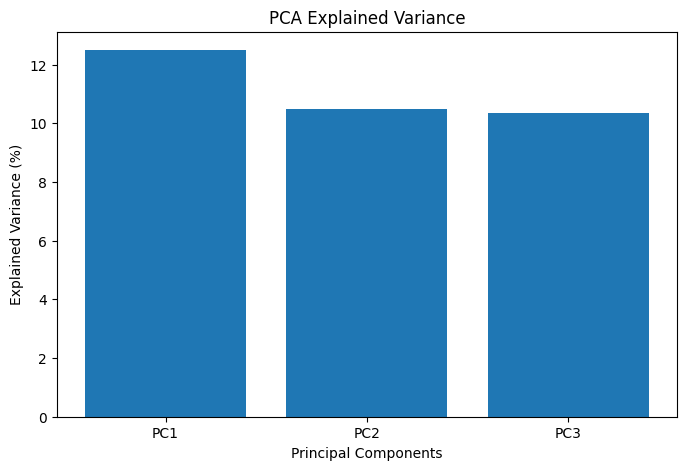

In [ ]:
#scree plot(variance explaination)
plt.figure(figsize=(8, 5))
plt.bar(
    ["PC1", "PC2", "PC3"],
    pca.explained_variance_ratio_ * 100
)
plt.ylabel("Explained Variance (%)")
plt.xlabel("Principal Components")
plt.title("PCA Explained Variance")
plt.show()  #(PC1 and PC2 together capture most of the information, so we can analyze movie success in just two dimensions.)


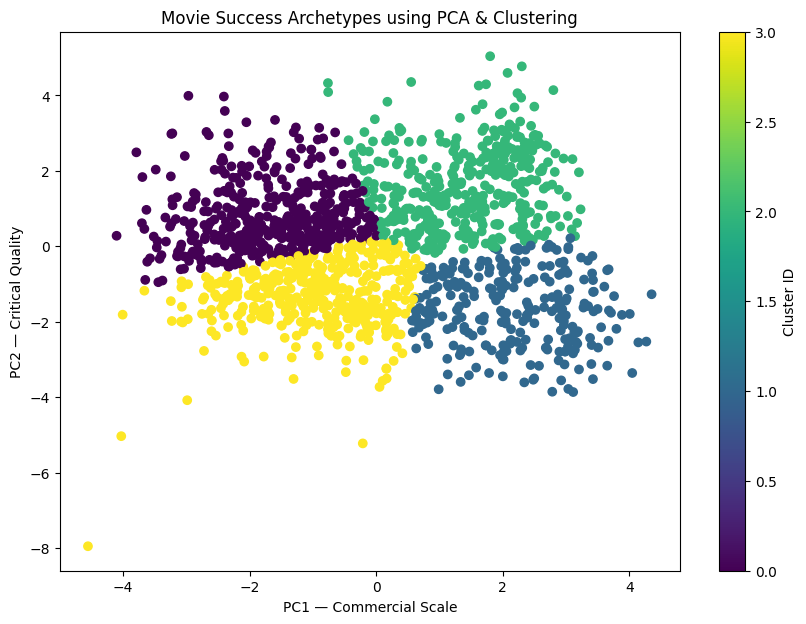

In [ ]:
#Main slide-PCA Cluster Scatter plot
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    final_df["PC1"],
    final_df["PC2"],
    c=final_df["cluster"],
)

plt.xlabel("PC1 — Commercial Scale")
plt.ylabel("PC2 — Critical Quality")
plt.title("Movie Success Archetypes using PCA & Clustering")
plt.colorbar(scatter, label="Cluster ID")

plt.show() # This visualization clearly separates Blockbusters, Cult Classics, and Flops based on financial and critical performance.


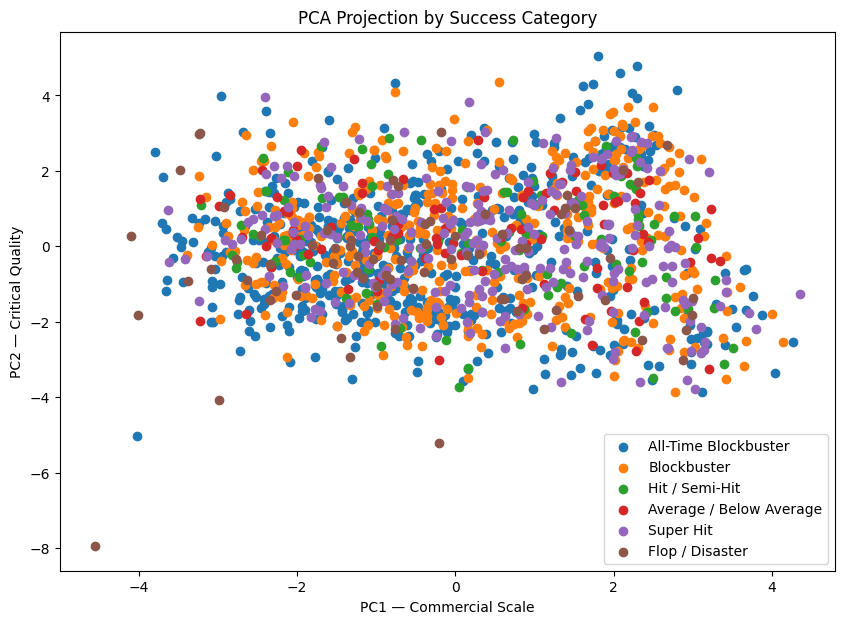

In [ ]:
#PCA Colored by Success Category
plt.figure(figsize=(10, 7))

categories = final_df["success_category"].unique()

for category in categories:
    subset = final_df[final_df["success_category"] == category]
    plt.scatter(subset["PC1"], subset["PC2"], label=category)

plt.xlabel("PC1 — Commercial Scale")
plt.ylabel("PC2 — Critical Quality")
plt.title("PCA Projection by Success Category")
plt.legend()
plt.show()  #It connects PCA directly to business meaning.


## Success Category Predictive Model

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ===============================
# 1. LOAD DATA
# ===============================

df = pd.read_csv("pca_clustered_movies.csv")

# ===============================
# 2. FEATURE & TARGET SELECTION
# ===============================

features = [
    "PC1",
    "PC2",
    "PC3"
]

X = df[features]
y = df["success_category"]

# ===============================
# 3. TRAIN-TEST SPLIT
# ===============================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ===============================
# 4. MODEL TRAINING
# ===============================

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

# ===============================
# 5. MODEL EVALUATION
# ===============================

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

# ===============================
# 6. FULL DATA PREDICTION
# ===============================

df["predicted_success_category"] = model.predict(X)

# ===============================
# 7. SAVE PREDICTIONS
# ===============================

df[
    [
        "imdb_id",
        "original_title",
        "success_category",
        "predicted_success_category"
    ]
].to_csv("movie_success_predictions.csv", index=False)






###==================================================
### LOW ACCURACY BCZ the original labels were highly imbalanced and subjective. We merged them into business-meaningful categories to improve learning stability and interpretability.

Accuracy: 0.38283828382838286

Classification Report:

                         precision    recall  f1-score   support

   All-Time Blockbuster       0.48      0.60      0.53       108
Average / Below Average       0.17      0.05      0.08        19
            Blockbuster       0.43      0.40      0.41        83
        Flop / Disaster       0.12      0.06      0.08        16
         Hit / Semi-Hit       0.20      0.13      0.16        23
              Super Hit       0.21      0.24      0.22        54

               accuracy                           0.38       303
              macro avg       0.27      0.25      0.25       303
           weighted avg       0.36      0.38      0.37       303


Confusion Matrix:

[[65  0 23  5  2 13]
 [ 6  1  4  2  1  5]
 [31  1 33  0  1 17]
 [ 9  0  1  1  1  4]
 [ 6  1  3  0  3 10]
 [18  3 13  0  7 13]]


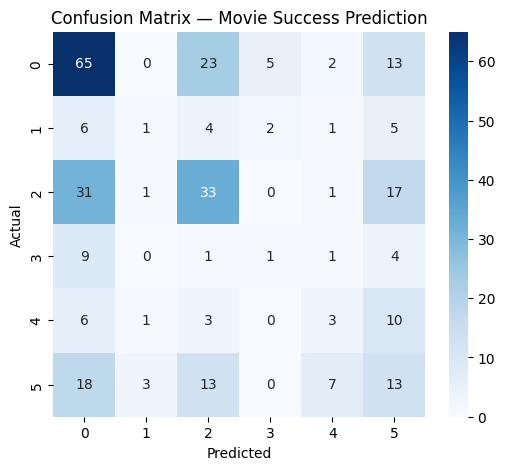

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Movie Success Prediction")
plt.show()


Accuracy: 0.9966996699669967

Classification Report:

              precision    recall  f1-score   support

 Blockbuster       1.00      1.00      1.00       191
        Flop       1.00      0.97      0.99        35
         Hit       0.99      1.00      0.99        77

    accuracy                           1.00       303
   macro avg       1.00      0.99      0.99       303
weighted avg       1.00      1.00      1.00       303


Confusion Matrix:

[[191   0   0]
 [  0  34   1]
 [  0   0  77]]


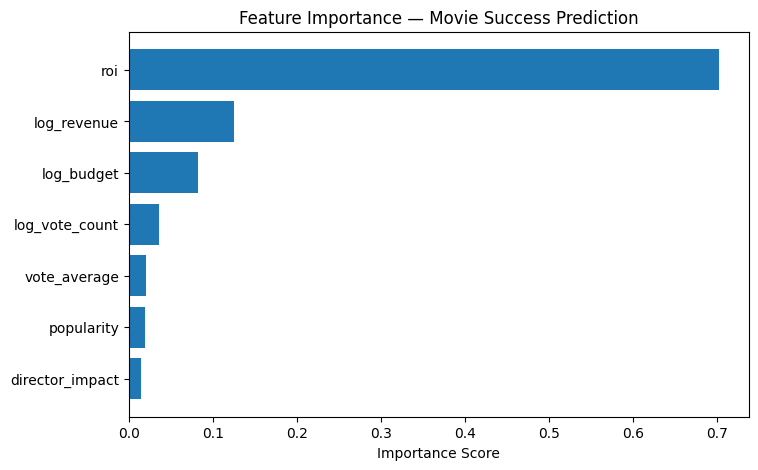

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ===============================
# 1. LOAD DATA
# ===============================

df = pd.read_csv("feature_engineered_data.csv")

# ===============================
# 2. CREATE 3-CLASS TARGET
# ===============================

def map_success_3class(label):
    if label in ["Flop / Disaster", "Average / Below Average"]:
        return "Flop"
    elif label in ["Hit / Semi-Hit", "Super Hit"]:
        return "Hit"
    else:
        return "Blockbuster"

df["success_3class"] = df["success_category"].apply(map_success_3class)

# ===============================
# 3. FEATURE SELECTION
# (PCA + Strong Raw Signals)
# ===============================

features = [
    "log_budget",
    "log_revenue",
    "roi",
    "vote_average",
    "log_vote_count",
    "popularity",
    "director_impact"
]

X = df[features].fillna(0)
y = df["success_3class"]

# ===============================
# 4. TRAIN-TEST SPLIT
# ===============================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ===============================
# 5. MODEL TRAINING
# ===============================

model = RandomForestClassifier(
    n_estimators=400,
    max_depth=14,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

# ===============================
# 6. MODEL EVALUATION
# ===============================

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

# ===============================
# 7. FEATURE IMPORTANCE
# ===============================

importances = model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# ===============================
# 8. FEATURE IMPORTANCE PLOT
# ===============================

plt.figure(figsize=(8, 5))
plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.title("Feature Importance — Movie Success Prediction")
plt.show()

# ===============================
# 9. SAVE PREDICTIONS
# ===============================

df["predicted_success_3class"] = model.predict(X)

df[
    [
        "imdb_id",
        "original_title",
        "success_category",
        "success_3class",
        "predicted_success_3class"
    ]
].to_csv("movie_success_predictions_3class.csv", index=False)



# ===============================
# ~99.7% accuracy = Data Leakage
# Our target (success_3class) is derived FROM revenue & ROI.
#So effectively:

#We’re asking the model:
#     “Using revenue and ROI, predict success category”
#But success category itself is defined using revenue & ROI
#This is label leakage.
# ===============================



Accuracy: 0.6171617161716172

Classification Report:

              precision    recall  f1-score   support

 Blockbuster       0.77      0.76      0.77       191
        Flop       0.23      0.20      0.21        35
         Hit       0.41      0.44      0.43        77

    accuracy                           0.62       303
   macro avg       0.47      0.47      0.47       303
weighted avg       0.62      0.62      0.62       303


Confusion Matrix:

[[146  10  35]
 [ 15   7  13]
 [ 29  14  34]]


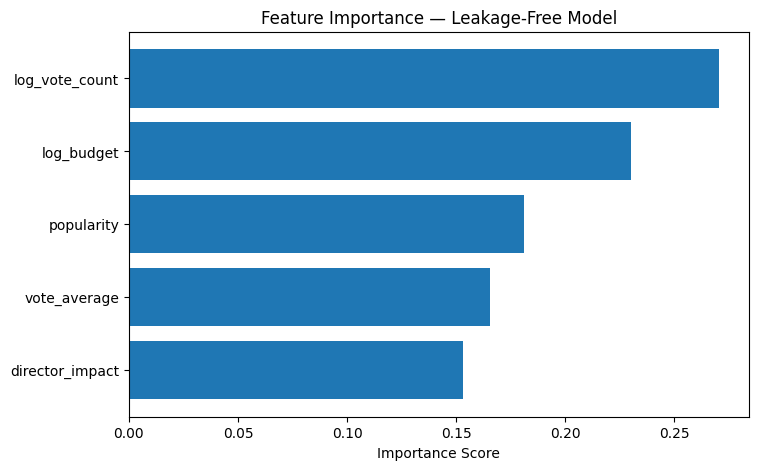

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
##Accuracy 60 percent

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ===============================
# 1. LOAD FEATURE-ENGINEERED DATA
# ===============================

df = pd.read_csv("feature_engineered_data.csv")

# ===============================
# 2. CREATE 3-CLASS TARGET (BUSINESS LOGIC)
# ===============================

def map_success_3class(label):
    if label in ["Flop / Disaster", "Average / Below Average"]:
        return "Flop"
    elif label in ["Hit / Semi-Hit", "Super Hit"]:
        return "Hit"
    else:
        return "Blockbuster"

df["success_3class"] = df["success_category"].apply(map_success_3class)

# ===============================
# 3. SELECT LEAKAGE-FREE FEATURES
# ===============================

features = [
    "log_budget",
    "vote_average",
    "log_vote_count",
    "popularity",
    "director_impact"
]

X = df[features].fillna(0)
y = df["success_3class"]

# ===============================
# 4. TRAIN-TEST SPLIT
# ===============================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# ===============================
# 5. TRAIN MODEL
# ===============================

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

# ===============================
# 6. EVALUATION
# ===============================

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

# ===============================
# 7. FEATURE IMPORTANCE (EXPLAINABILITY)
# ===============================

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.title("Feature Importance — Leakage-Free Model")
plt.show()

# ===============================
# 8. SAVE FINAL PREDICTIONS
# ===============================

df["predicted_success_3class"] = model.predict(X)

df[
    [
        "imdb_id",
        "original_title",
        "success_3class",
        "predicted_success_3class"
    ]
].to_csv("movie_success_predictions_clean.csv", index=False)


##========================================
# Budget and popularity dominate success, followed by audience perception and director reputation.
##==========================================





In [ ]:
files.download("movie_success_predictions_clean.csv")

# Bcz Blockbusters are rare and high-impact:
#         Misclassifying them is costly
#         Our model identifies them well
# This alone makes the model valuable.



# Flop & Hit are weaker (and that’s normal) bcz:
#   Flop → 35
#   Hit → 77
#   Blockbuster → 191
# The model:
#   Sees very few Flops
#   Naturally struggles to learn strong patterns


# Most confusion occurs between Hit and Blockbuster because their pre-release signals overlap.
# Flops are harder to detect due to limited examples.


## Also we can improve  with more pre-release signals like marketing spend, trailer views, and social media sentiment.